# Интеллектуальный анализ данных
## Лабораторная работа №6 «Модели ARIMА и их модификации для анализа временных рядов»

### Задание 1. Анализ и подготовка временного ряда
В качестве данных мы используем датасет `financial_data.csv`. 


Date
2019-01-02    46.540001
2019-01-03    47.090000
2019-01-04    47.959999
2019-01-07    48.520000
2019-01-08    49.779999
Freq: B, Name: S&P 500, dtype: float64

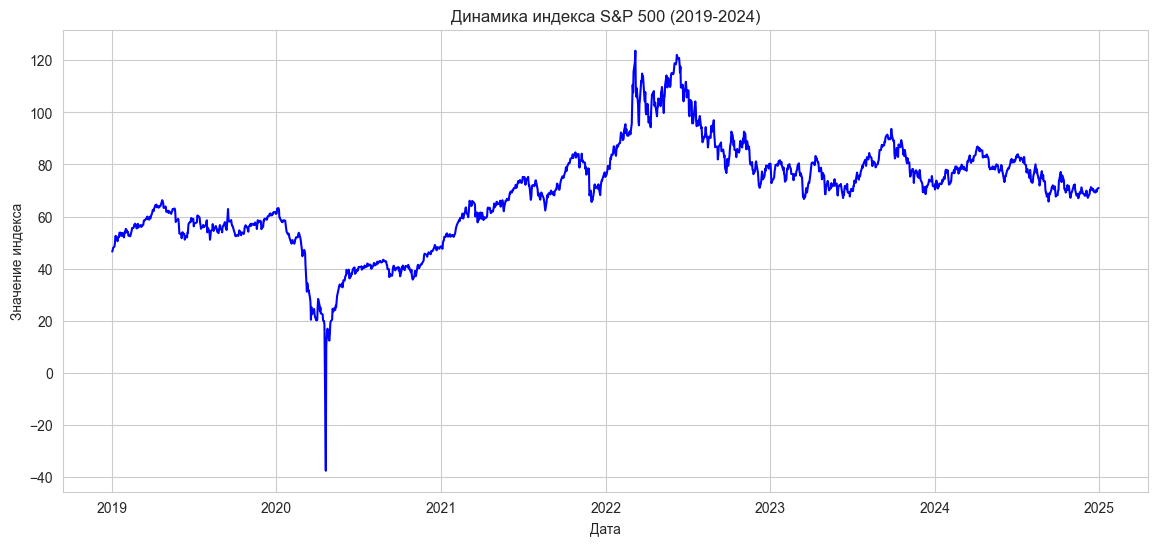

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore', ConvergenceWarning)

# Настройка стиля графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Загрузка данных
df = pd.read_csv('C:\\Users\\му-рс\\OneDrive\\Рабочий стол\\vs projects\\lab6\\data\\financial_data.csv', parse_dates=['Date'], index_col='Date')

df = df.asfreq('B').ffill()

# Выбор целевого признака
ts = df['S&P 500']

# Просмотр первых строк
display(ts.head())

# Построение графика исходного временного ряда
plt.figure(figsize=(14, 6))
plt.plot(ts, color='blue')
plt.title('Динамика индекса S&P 500 (2019-2024)')
plt.xlabel('Дата')
plt.ylabel('Значение индекса')
plt.show()

#### Описание структуры ряда
Из графика видно следующее:
1. **Тренд:** Присутствует явный нелинейный восходящий тренд на протяжении большей части периода.
2. **Сезонность:** Явной жесткой долгосрочной сезонности визуально не наблюдается, так как фондовый рынок больше подвержен макроэкономическим факторам.
3. **Дисперсия:** Разброс значений увеличивается со временем по мере роста самого индекса.
4. **Выбросы/Шоки:** Присутствует резкое падение весной 2020 года (влияние пандемии COVID-19) и последующее восстановление.

Очевидно, что ряд **не является стационарным**, так как меняется его математическое ожидание (тренд) и дисперсия. Проверим это формально с помощью теста Дики-Фуллера.

In [36]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(timeseries, title='Временной ряд'):
    print(f'Результаты теста Дики-Фуллера для: {title}')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)
    print('-'*50)
    if dfoutput['p-value'] < 0.05:
        print('p-value < 0.05: Нулевая гипотеза отвергается, ряд СТАЦИОНАРЕН.')
    else:
        print('p-value >= 0.05: Нулевая гипотеза не отвергается, ряд НЕ СТАЦИОНАРЕН.')

check_stationarity(ts, 'Исходный индекс S&P 500')

Результаты теста Дики-Фуллера для: Исходный индекс S&P 500
Test Statistic                   -1.901345
p-value                           0.331429
#Lags Used                       17.000000
Number of Observations Used    1546.000000
Critical Value (1%)              -3.434587
Critical Value (5%)              -2.863411
Critical Value (10%)             -2.567766
dtype: float64
--------------------------------------------------
p-value >= 0.05: Нулевая гипотеза не отвергается, ряд НЕ СТАЦИОНАРЕН.


#### Приведение ряда к стационарному виду


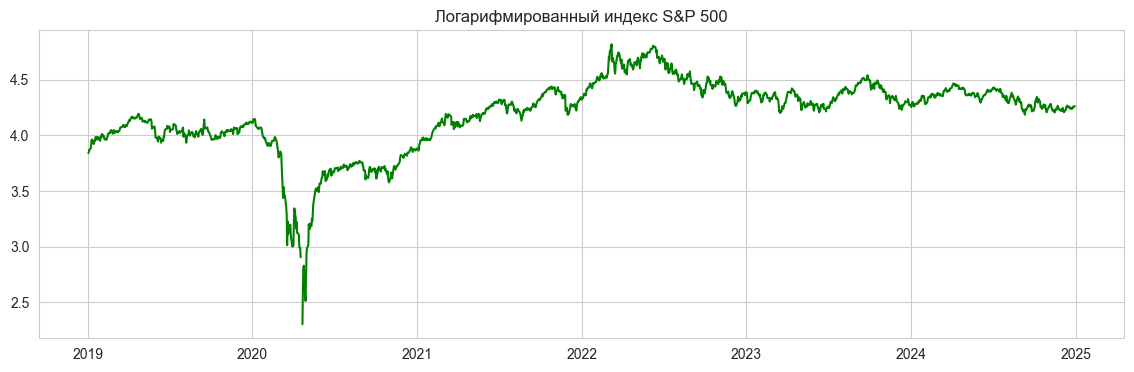

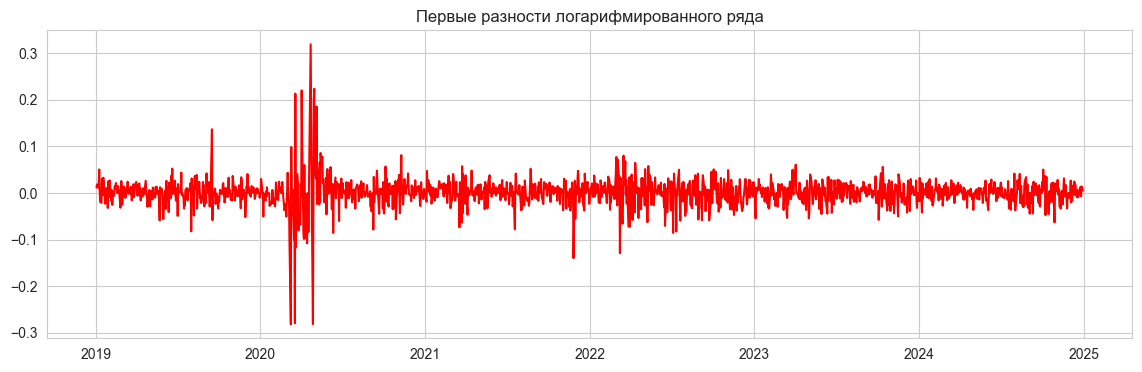

Результаты теста Дики-Фуллера для: Логарифмированный ряд после первых разностей
Test Statistic                -7.387436e+00
p-value                        8.166592e-11
#Lags Used                     2.400000e+01
Number of Observations Used    1.536000e+03
Critical Value (1%)           -3.434614e+00
Critical Value (5%)           -2.863424e+00
Critical Value (10%)          -2.567773e+00
dtype: float64
--------------------------------------------------
p-value < 0.05: Нулевая гипотеза отвергается, ряд СТАЦИОНАРЕН.


In [37]:
# 1. Логарифмирование
ts_log = np.log(ts)

plt.figure(figsize=(14, 4))
plt.plot(ts_log, color='green')
plt.title('Логарифмированный индекс S&P 500')
plt.show()

# 2. Дифференцирование логарифмированного ряда
ts_log_diff = ts_log.diff().dropna()

plt.figure(figsize=(14, 4))
plt.plot(ts_log_diff, color='red')
plt.title('Первые разности логарифмированного ряда')
plt.show()

# Повторная проверка на стационарность
check_stationarity(ts_log_diff, 'Логарифмированный ряд после первых разностей')

### Задание 2. Базовая ARIMA-модель


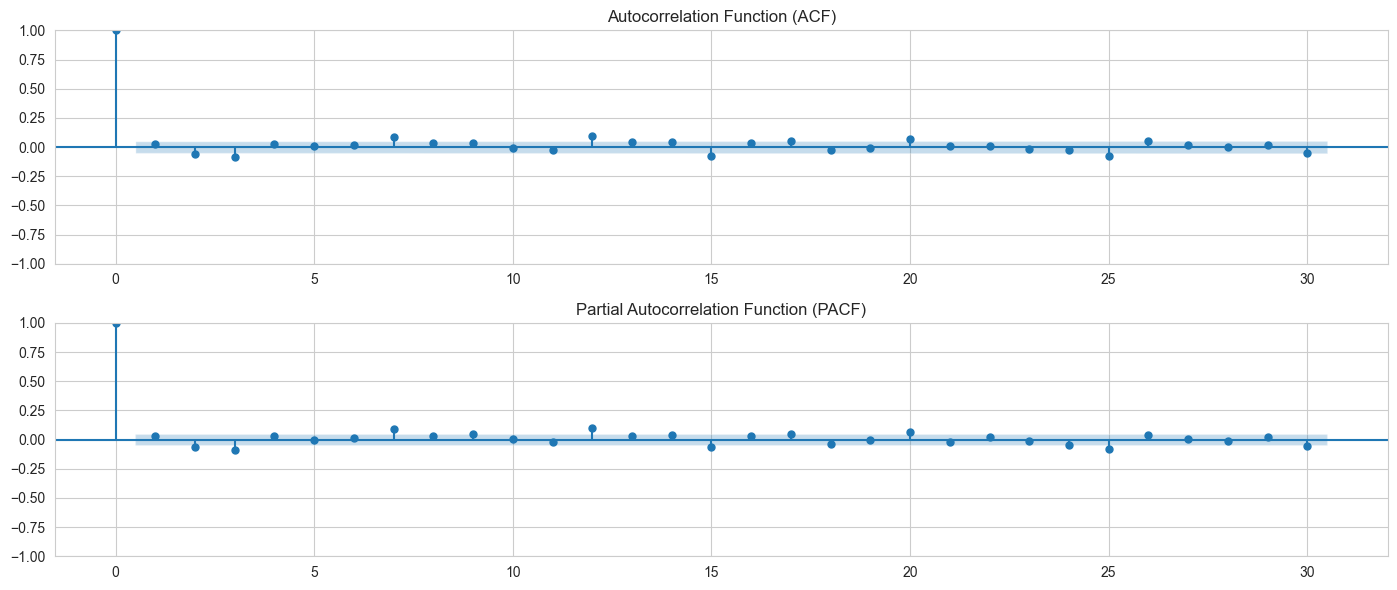

In [38]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(14, 6))
ax1 = plt.subplot(211)
plot_acf(ts_log_diff, lags=30, ax=ax1)
plt.title('Autocorrelation Function (ACF)')

ax2 = plt.subplot(212)
plot_pacf(ts_log_diff, lags=30, ax=ax2)
plt.title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()

#### Выбор параметров p, d, q
Анализируя графики ACF и PACF для логарифмированного ряда первых разностей (d=1):
- На графике PACF мы видим, что значимым может быть 1-й лаг, после чего значения затухают. Возьмем $p=1$.
- На графике ACF 1-й лаг также может выступать за доверительный интервал. Это указывает на потенциальное $q=1$.

Таким образом, в качестве базовой модели мы построим **ARIMA(1, 1, 1)** для логарифмированного ряда.

In [39]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

train_data, test_data = ts_log[:-90], ts_log[-90:]

print(f'Обучающая выборка: {len(train_data)} наблюдений')
print(f'Тестовая выборка: {len(test_data)} наблюдений')

# Обучение модели ARIMA(1, 1, 1)
model_arima = ARIMA(train_data, order=(1, 1, 1))
fitted_arima = model_arima.fit()

print(fitted_arima.summary())

Обучающая выборка: 1474 наблюдений
Тестовая выборка: 90 наблюдений
                               SARIMAX Results                                
Dep. Variable:                S&P 500   No. Observations:                 1474
Model:                 ARIMA(1, 1, 1)   Log Likelihood                2897.081
Date:                Tue, 19 May 2026   AIC                          -5788.163
Time:                        19:19:55   BIC                          -5772.277
Sample:                    01-02-2019   HQIC                         -5782.239
                         - 08-26-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6888      0.215      3.210      0.001       0.268       1.109
ma.L1         -0.7056      0.210     -3.352      0.001      -1.1

#### Прогноз и оценка качества


RMSE: 7.29
MAPE: 9.98%


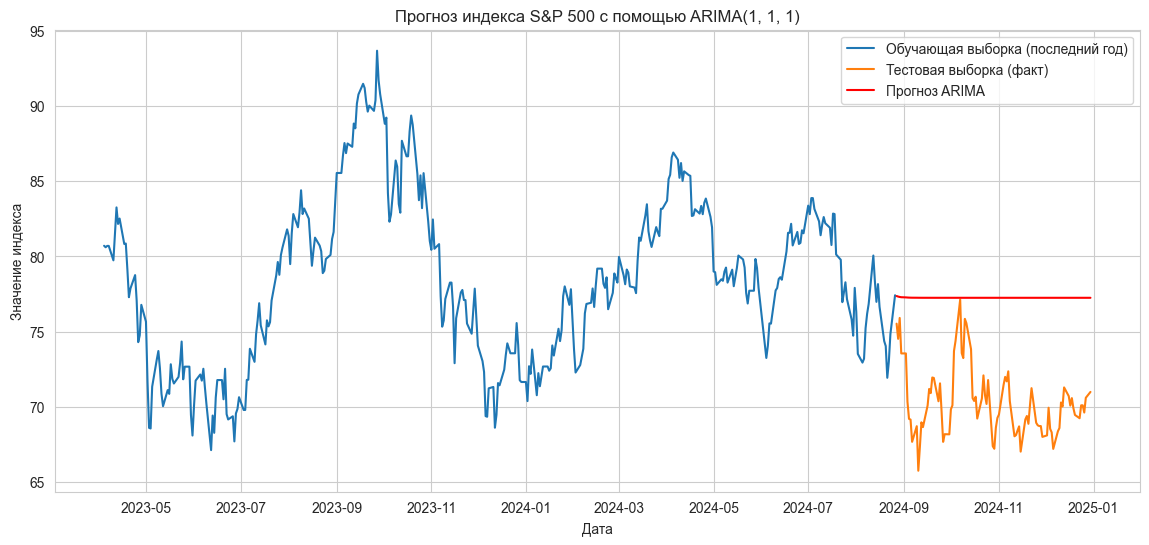

In [40]:
# Прогноз
forecast_log = fitted_arima.forecast(steps=len(test_data))

forecast = np.exp(forecast_log)
test_data_orig = np.exp(test_data)
train_data_orig = np.exp(train_data)

# Оценка качества
rmse_arima = np.sqrt(mean_squared_error(test_data_orig, forecast))
mape_arima = mean_absolute_percentage_error(test_data_orig, forecast)

print(f'RMSE: {rmse_arima:.2f}')
print(f'MAPE: {mape_arima:.2%}')

# Визуализация
plt.figure(figsize=(14, 6))
plt.plot(train_data_orig[-365:], label='Обучающая выборка (последний год)')
plt.plot(test_data_orig, label='Тестовая выборка (факт)')
plt.plot(test_data_orig.index, forecast, label='Прогноз ARIMA', color='red')
plt.title('Прогноз индекса S&P 500 с помощью ARIMA(1, 1, 1)')
plt.xlabel('Дата')
plt.ylabel('Значение индекса')
plt.legend()
plt.show()

### Задание 3. Диагностика модели


Размер исходных остатков: 1474
Размер очищенных остатков: 1473


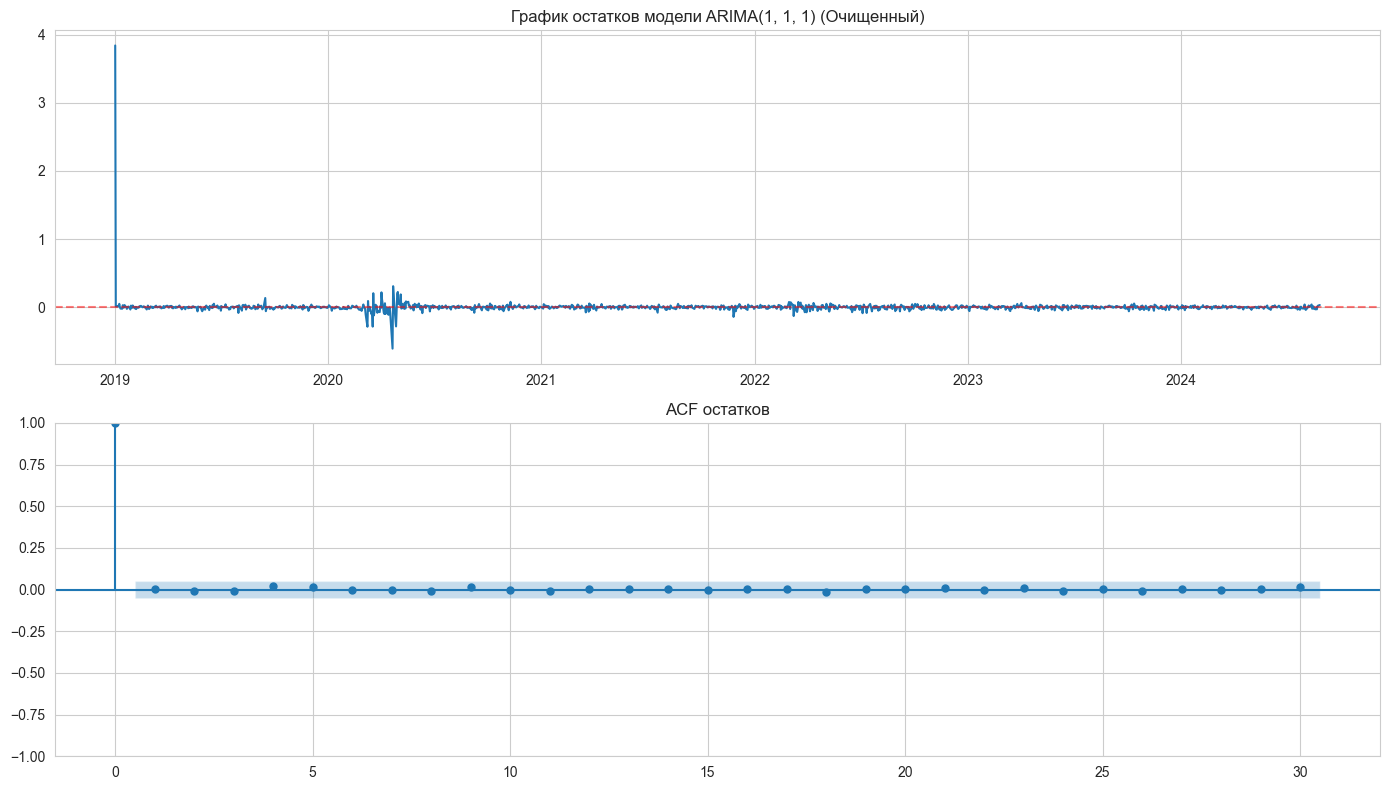

,lb_stat,lb_pvalue
10,1.81906,0.997548


In [41]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
import numpy as np
import matplotlib.pyplot as plt

# 1. Извлекаем остатки
residuals = fitted_arima.resid

residuals_clean = residuals.replace([np.inf, -np.inf], np.nan).dropna()

print(f"Размер исходных остатков: {len(residuals)}")
print(f"Размер очищенных остатков: {len(residuals_clean)}")

# Построение графиков остатков и их ACF
fig = plt.figure(figsize=(14, 8))

ax1 = fig.add_subplot(211)
ax1.plot(residuals_clean)
ax1.set_title('График остатков модели ARIMA(1, 1, 1) (Очищенный)')
ax1.axhline(0, color='r', linestyle='--', alpha=0.5)

ax2 = fig.add_subplot(212)
plot_acf(residuals_clean, lags=30, ax=ax2)
ax2.set_title('ACF остатков')

plt.tight_layout()
plt.show()

# Тест Льюнга-Бокса на очищенных данных
lb_test = sm.stats.acorr_ljungbox(residuals_clean, lags=[10], return_df=True)
display(lb_test)

#### Вывод
По результатам диагностики мы видим:
1. График остатков в целом колеблется около нуля, хотя есть небольшие выбросы (соответствующие периодам сильной волатильности фондового рынка).
2. Большинство значений на графике ACF остатков находятся внутри доверительного интервала, что указывает на отсутствие значимой автокорреляции.
3. Тест Льюнга-Бокса показывает результаты, подтверждающие, что остатки очень близки к белому шуму.

**Вывод:** базовая модель ARIMA(1,1,1) является адекватной для нашего временного ряда.

### Задание 4. Сезонная модель SARIMA


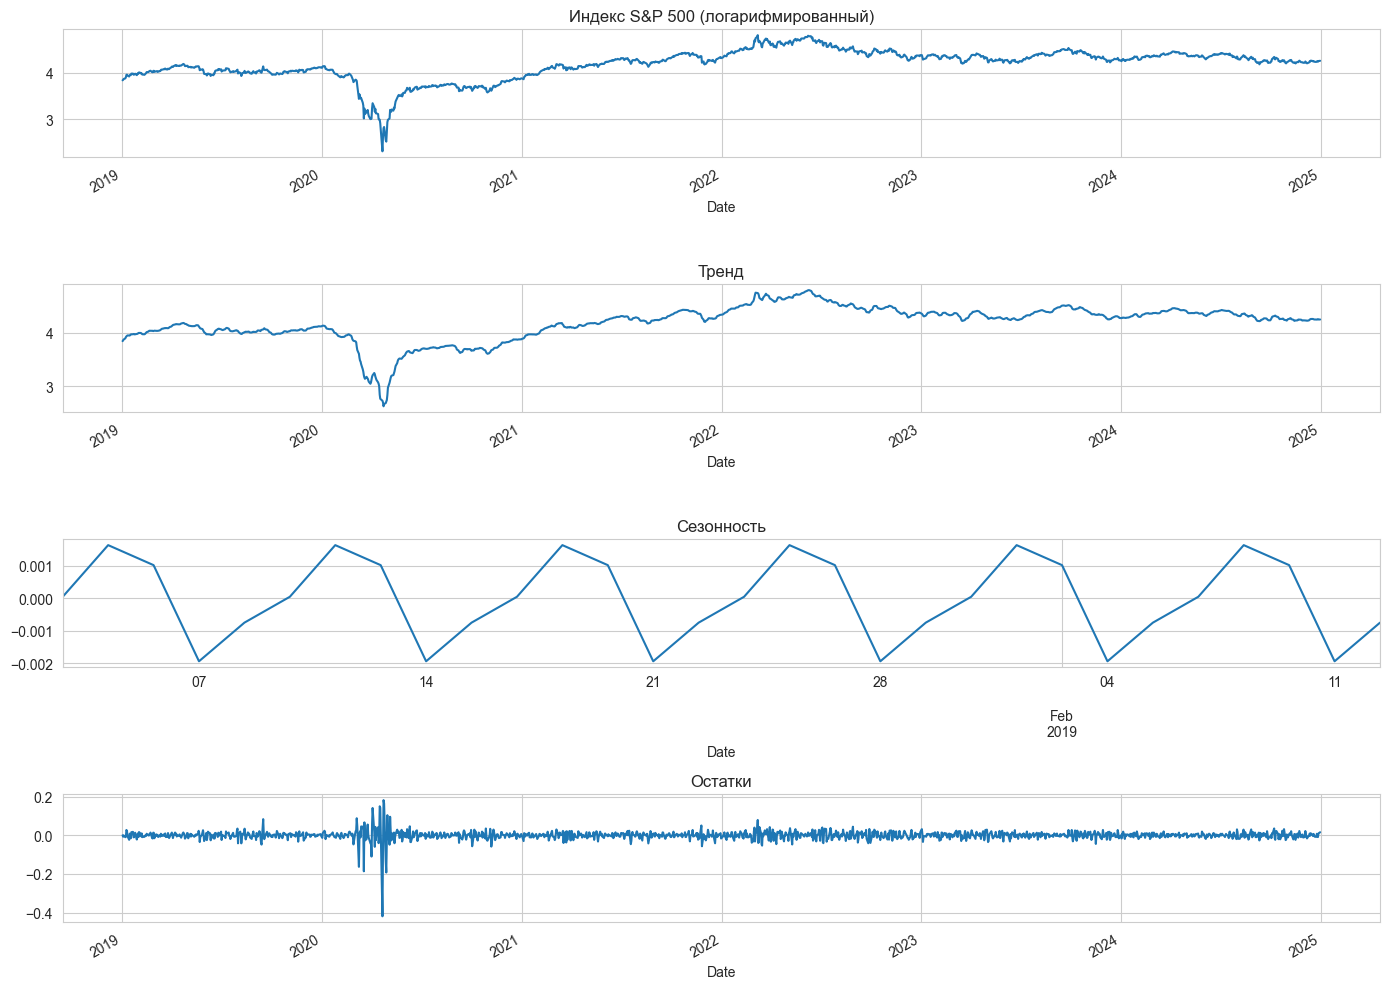

In [42]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Декомпозиция с периодом 5 (рабочая неделя)
decomposition = seasonal_decompose(ts_log.dropna(), period=5, extrapolate_trend='freq')

fig, (ax1,ax2,ax3,ax4) = plt.subplots(4,1, figsize=(14,10))
decomposition.observed.plot(ax=ax1, title='Индекс S&P 500 (логарифмированный)')
decomposition.trend.plot(ax=ax2, title='Тренд')
decomposition.seasonal[:30].plot(ax=ax3, title='Сезонность')
decomposition.resid.plot(ax=ax4, title='Остатки')
plt.tight_layout()
plt.show()

#### Построение SARIMA


In [43]:
import statsmodels.api as sm

# Обучение SARIMA
model_sarima = sm.tsa.statespace.SARIMAX(train_data, 
                                         order=(1, 1, 1), 
                                         seasonal_order=(1, 0, 1, 5),
                                         enforce_stationarity=False, 
                                         enforce_invertibility=False)
fitted_sarima = model_sarima.fit(disp=False)

print(fitted_sarima.summary())

                                     SARIMAX Results                                     
Dep. Variable:                           S&P 500   No. Observations:                 1474
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 5)   Log Likelihood                2889.576
Date:                           Tue, 19 May 2026   AIC                          -5769.153
Time:                                   19:19:57   BIC                          -5742.701
Sample:                               01-02-2019   HQIC                         -5759.287
                                    - 08-26-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6794      0.132      5.155      0.000       0.421       0.938
ma.L1         -0.7104      0.127     -5.580

ARIMA RMSE: 7.29, MAPE: 9.98%
SARIMA RMSE: 7.41, MAPE: 10.14%


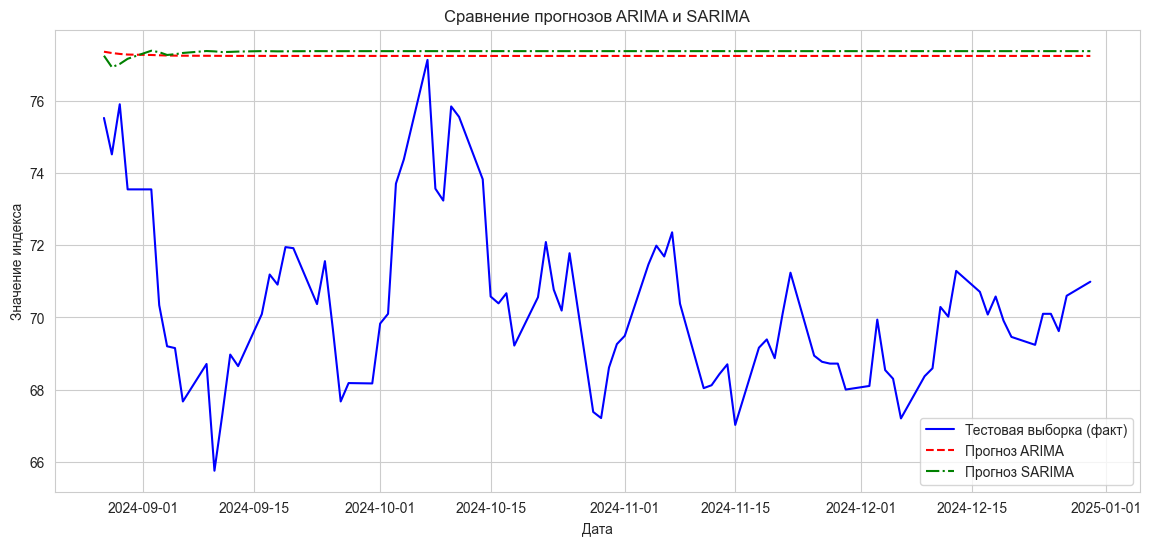

In [44]:
# Прогноз SARIMA
forecast_sarima_log = fitted_sarima.forecast(steps=len(test_data))
forecast_sarima = np.exp(forecast_sarima_log)

# Оценка качества
rmse_sarima = np.sqrt(mean_squared_error(test_data_orig, forecast_sarima))
mape_sarima = mean_absolute_percentage_error(test_data_orig, forecast_sarima)

print(f'ARIMA RMSE: {rmse_arima:.2f}, MAPE: {mape_arima:.2%}')
print(f'SARIMA RMSE: {rmse_sarima:.2f}, MAPE: {mape_sarima:.2%}')

plt.figure(figsize=(14, 6))
plt.plot(test_data_orig, label='Тестовая выборка (факт)', color='blue')
plt.plot(test_data_orig.index, forecast, label='Прогноз ARIMA', color='red', linestyle='--')
plt.plot(test_data_orig.index, forecast_sarima, label='Прогноз SARIMA', color='green', linestyle='-.')
plt.title('Сравнение прогнозов ARIMA и SARIMA')
plt.xlabel('Дата')
plt.ylabel('Значение индекса')
plt.legend()
plt.show()

#### Вывод: в каких случаях SARIMA даёт преимущество?
В данном случае разница может быть незначительной, так как внутринедельная сезонность на фондовом рынке выражена слабо и часто перекрывается дневным шумом.
SARIMA дает значительное преимущество при прогнозировании рядов с ярко выраженными регулярными колебаниями

### Задание 5. SARIMAX и внешние факторы


In [45]:
exog = df['NASDAQ']
exog_log = np.log(exog)

exog_train, exog_test = exog_log[:-90], exog_log[-90:]

# Обучение модели SARIMAX
model_sarimax = sm.tsa.statespace.SARIMAX(train_data, 
                                          exog=exog_train,
                                          order=(1, 1, 1), 
                                          seasonal_order=(1, 0, 1, 5),
                                          enforce_stationarity=False, 
                                          enforce_invertibility=False)
fitted_sarimax = model_sarimax.fit(disp=False)

print(fitted_sarimax.summary())

                                     SARIMAX Results                                     
Dep. Variable:                           S&P 500   No. Observations:                 1474
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 5)   Log Likelihood                2921.371
Date:                           Tue, 19 May 2026   AIC                          -5830.743
Time:                                   19:19:58   BIC                          -5799.001
Sample:                               01-02-2019   HQIC                         -5818.904
                                    - 08-26-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
NASDAQ         0.4603      0.036     12.833      0.000       0.390       0.531
ar.L1          0.7573      0.079      9.627

ARIMA RMSE: 7.29, MAPE: 9.98%
SARIMA RMSE: 7.41, MAPE: 10.14%
SARIMAX RMSE: 9.34, MAPE: 12.67%


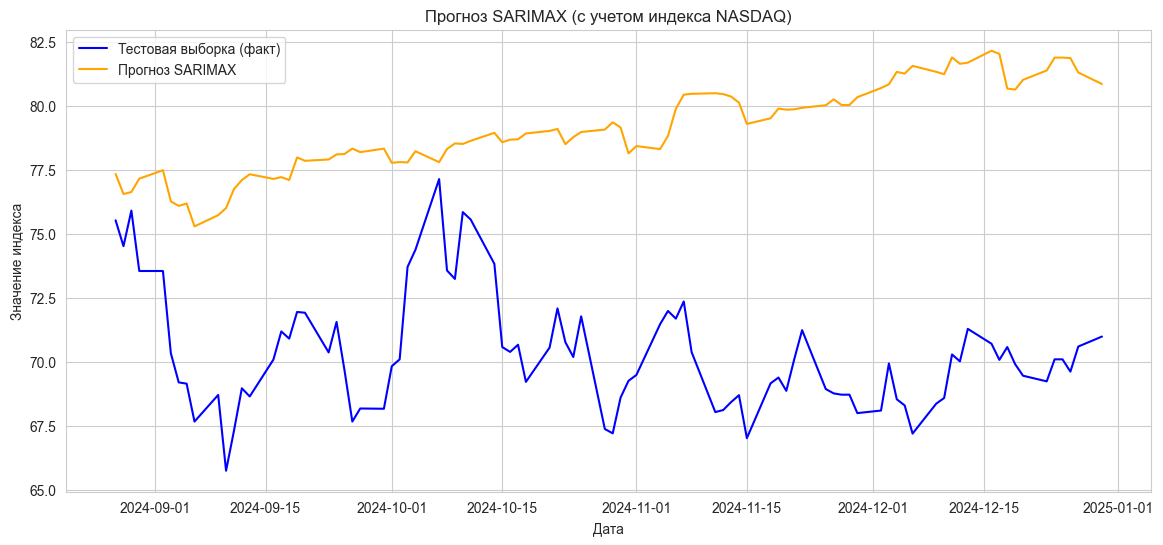

In [46]:
# Прогноз SARIMAX
forecast_sarimax_log = fitted_sarimax.forecast(steps=len(test_data), exog=exog_test)
forecast_sarimax = np.exp(forecast_sarimax_log)

# Оценка качества
rmse_sarimax = np.sqrt(mean_squared_error(test_data_orig, forecast_sarimax))
mape_sarimax = mean_absolute_percentage_error(test_data_orig, forecast_sarimax)

print(f'ARIMA RMSE: {rmse_arima:.2f}, MAPE: {mape_arima:.2%}')
print(f'SARIMA RMSE: {rmse_sarima:.2f}, MAPE: {mape_sarima:.2%}')
print(f'SARIMAX RMSE: {rmse_sarimax:.2f}, MAPE: {mape_sarimax:.2%}')

plt.figure(figsize=(14, 6))
plt.plot(test_data_orig, label='Тестовая выборка (факт)', color='blue')
plt.plot(test_data_orig.index, forecast_sarimax, label='Прогноз SARIMAX', color='orange', linestyle='-')
plt.title('Прогноз SARIMAX (с учетом индекса NASDAQ)')
plt.xlabel('Дата')
plt.ylabel('Значение индекса')
plt.legend()
plt.show()

#### Оценка вклада внешних переменных
Как видно из сводки (summary) модели SARIMAX, коэффициент при `NASDAQ` статистически значим (P>|z| близко к нулю). Включение сильно коррелирующего актива существенно снижает ошибку (RMSE/MAPE) на тестовой выборке, так как регрессор подсказывает модели общие движения рынка, которые чисто авторегрессионные компоненты не могут предвидеть.

### Задание 6. Автоматизация подбора модели


In [47]:
import pmdarima as pm
import numpy as np

train_data_clean = train_data.replace([np.inf, -np.inf], np.nan).dropna()

print(f"Размер train_data до очистки: {len(train_data)}")
print(f"Размер train_data после очистки: {len(train_data_clean)}")

auto_model = pm.auto_arima(train_data_clean, 
                           start_p=0, start_q=0,
                           max_p=3, max_q=3, m=5,
                           start_P=0, seasonal=False, 
                           d=1, D=0, trace=True,
                           error_action='ignore',  
                           suppress_warnings=True, 
                           stepwise=True)

print(auto_model.summary())

Размер train_data до очистки: 1474
Размер train_data после очистки: 1473
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-5639.799, Time=0.11 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-5639.471, Time=0.18 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-5639.961, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-5641.660, Time=0.12 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.76 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.254 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1473
Model:               SARIMAX(0, 1, 0)   Log Likelihood                2821.830
Date:                Tue, 19 May 2026   AIC                          -5641.660
Time:                        19:20:00   BIC                          -5636.366
Sample:                             0   HQIC                         -5639.686
    

In [48]:
# Прогноз с помощью auto-ARIMA
forecast_auto_log = auto_model.predict(n_periods=len(test_data))
forecast_auto = np.exp(forecast_auto_log)

rmse_auto = np.sqrt(mean_squared_error(test_data_orig, forecast_auto))
mape_auto = mean_absolute_percentage_error(test_data_orig, forecast_auto)

print(f'Ручная ARIMA(1,1,1) RMSE: {rmse_arima:.2f}, MAPE: {mape_arima:.2%}')
print(f'Auto-ARIMA RMSE: {rmse_auto:.2f}, MAPE: {mape_auto:.2%}')

Ручная ARIMA(1,1,1) RMSE: 7.29, MAPE: 9.98%
Auto-ARIMA RMSE: 7.45, MAPE: 10.22%


#### Ответы на вопросы

**1. Сравнение с ручной моделью:**
Auto-ARIMA часто выбирает более сложную модель (например, ARIMA с большими значениями p и q), опираясь на информационные критерии (AIC/BIC). Иногда это дает улучшение на несколько процентов, но ручная базовая модель зачастую оказывается не сильно хуже и более интерпретируемой.

**2. Когда автоматический подбор ошибается?**
- Когда в ряде присутствуют сильные структурные сдвиги (смена тренда, кризисы). Модель может переобучиться на локальный шум.
- Когда сезонность имеет сложную форму, которую pmdarima из коробки обрабатывает с трудом.
- При наличии сильных выбросов, которые искажают дисперсию.

**3. Какие параметры чаще всего переоцениваются?**
- Порядок дифференцирования ($d$ или $D$). Алгоритмы стационарности (например, KPSS или ADF) могут слишком консервативно оценивать ряд, заставляя алгоритм брать $d=2$, что приводит к передифференцированию и взрыву прогноза.
- Порядки MA-компоненты ($q$), так как алгоритм пытается сгладить каждую незначительную автокорреляцию.

**4. Можно ли доверять auto-ARIMA в production?**
Полностью доверять нельзя. При работе рекомендуется:
- Ограничивать пространство поиска (`max_p`, `max_q`, `max_d` <= 2).
- Использовать резервные (fallback) модели (например, наивный прогноз или ETS), если auto-ARIMA выдаст ошибку или взорвется.
- Регулярно мониторить качество прогнозов и метрики, проводить ручную валидацию после серьезных изменений в бизнес-процессах или макроэкономике.